Note: since most of the problem subsections rely on multiple functions (from different code files), all files are attached at the end of the document. The heat_rod.py file is from homework 01. Thank you.

# 1.1

$q_{MAP} = [ Φ = -17.560427 W/cm²,  h = 0.001814 W/cm²/°C]$ 


Acceptance ratio = 0.799 (near/at 1000/1000 sample)

# 1.2

Shape of observations: (15,)

Running Adaptive Metropolis algorithm for 1000 iterations...
Initial proposal distribution (first 100 iterations): N(q_prev, D) with D = diag([0.01, 2e-10])
AM parameters: sp = 2.38^2/2 = 2.8322, k0 = 100

Final acceptance rate: 0.971

PROBLEM 2.1 RESULTS

At k=101, the new Vk generated from the first 100 samples is:
Vk = None

PROBLEM 2.2 RESULTS

At k=M, the final Vk generated is:
Vk = [0. 0.]

Computing posterior values for MAP estimate...

Computing posterior values for MAP estimate...

PROBLEM 1.1 RESULTS

MAP Estimate (q_MAP):
  Φ = -17.630455 W/cm²
  h = 0.001815 W/cm²/°C
  π(υ|q_MAP)π0(q_MAP) = 5.57e-03

Posterior Distribution π(q|υ) Summary:
Φ:
  Mean = -18.386192 W/cm²
  Std  = 0.852256 W/cm²
  95% CI = [-19.687854, -15.972287]

h:
  Mean = 1.910262e-03 W/cm²/°C
  Std  = 5.559441e-05 W/cm²/°C
  95% CI = [1.820570e-03, 2.021652e-03]


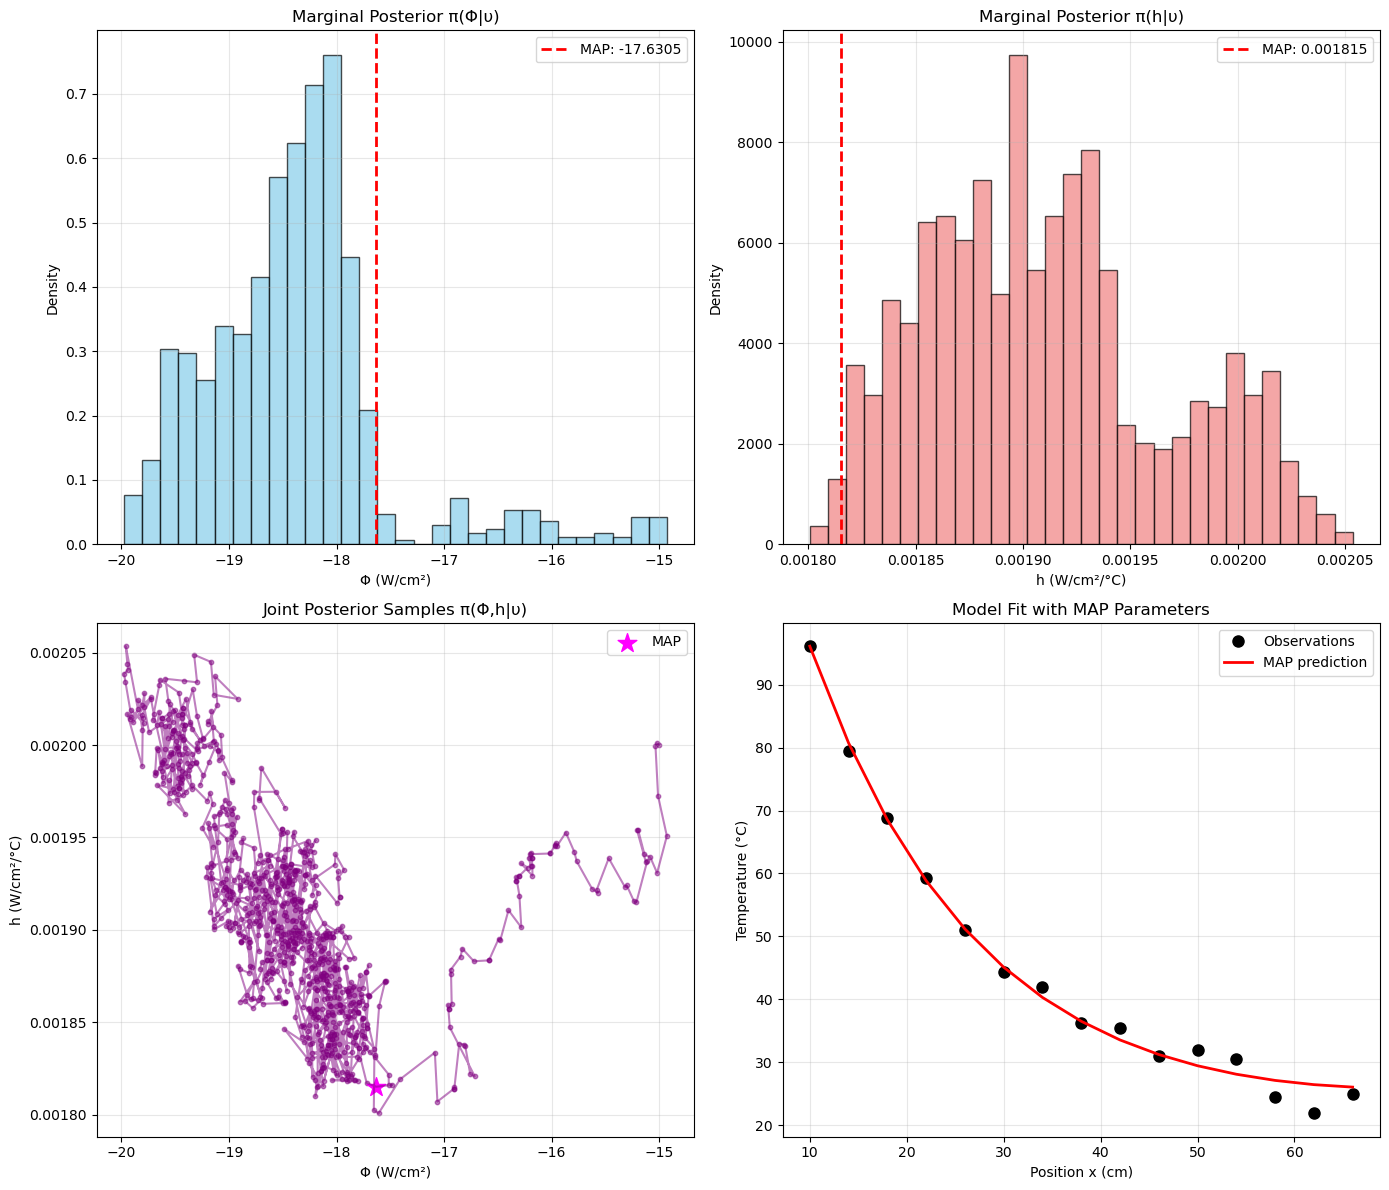


Results saved to 'problem1.2_results.npz'


0.970970970970971

In [7]:
from am_mcmc import *
M=1000
samples, posterior_values, q_map, Vk_at_101, acceptance_rate \
    = run_adaptive_metropolis_for_heat_equation(M = M, func = 'drm', k_for_am = M**2, burn = 0, title = '1.2: DRM, no Gibbs', data_filename='HW06_Problem1.mat', )

# Save results
np.savez('problem1.2_results.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)

print(f"\nResults saved to 'problem1.2_results.npz'")
acceptance_rate

In [18]:
samples[np.argmax(posterior_values[300:])] # accounting for burn-in when selecting MAP


array([-1.5e+01,  2.0e-03])

MAP estimate:   [Φ = -17.334279 W/cm²,  h = 0.001790 W/cm²/°C]
Removing Burn-in and recalculating MAP: MAP estimate:   [Φ = -15 W/cm²,  h = 0.002 W/cm²/°C]

Acceptance ratio: 0.992

# 1.3 - DR influence on results

1.  The acceptance ratio increases with DR since the rejected proposlas get a second chance to be accepted via  a scaled-down proposal covariance. Thes econd stage proposal explores more locally around the rejected point, thus enabling a potential acceptance of a state that would otherwise be rejected. 
2. The MAP estimate is relatively stable between the two algorithms used; DR will allow the chain to explore the parameter space more thoroughly, thus enabling the algorithm to better characterize different modes. This is especially apparent through the marginal distribution plots (specifically for $\phi$); with the DR algorithm we get a more spread out distribution, indicating the exploration of multiple modes rather than a concentration of samples about one single mode. The narrow second stage proposal will also help in fine-tuning the proposals/distribution approximation around high probability regions. 
3. DR generally improves chain mixing by reducing the number of stuck states; the autocorrelation in the chain decreases leading to more effective samples.  
